### Business Problem Statement
#### Context:
Britam, like most insurers, prices health/medical cover based on risk factors tied to the policyholder — age, lifestyle, and pre-existing health indicators. Underpricing high-risk policyholders erodes underwriting margins; overpricing low-risk policyholders hurts competitiveness and retention. Accurately estimating expected claim cost at the point of underwriting is therefore central to sustainable pricing.

#### Problem:
Given policyholder demographic and lifestyle attributes (age, sex, BMI, number of dependents, smoking status, and region), can we predict the expected medical insurance charges for a policyholder, and identify which factors drive cost the most?

#### Objective:

1. Build a regression model that estimates expected charges from policyholder attributes, to support risk-based pricing decisions.
2. Identify and quantify the key cost drivers (e.g., smoking status, BMI, age) to inform underwriting guidelines and wellness-program targeting.
3. Visualize cost patterns by segment/region to help pricing and product teams spot high-risk pools and pricing gaps.

#### Business Value:

- More accurate risk-based pricing ---> improved loss ratio and underwriting profitability
- Early identification of high-cost segments ---> targeted wellness/prevention interventions (e.g., smoking cessation programs) to reduce future claims
- Regional/segment visibility ---> informs product strategy and resource allocation across markets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./potential_data/mirichoi0218_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis

In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
non_numeric_cols = df.select_dtypes(exclude='number').columns

non_numeric_cols

Index(['sex', 'smoker', 'region'], dtype='object')

In [7]:
label_max = df['sex'].value_counts().idxmax()
label_min = df['sex'].value_counts().idxmin()

value_max = df['sex'].value_counts().iloc[0]
value_min = df['sex'].value_counts().iloc[1]


In [8]:
unique_value_counts = []

for col in non_numeric_cols:
    labels = df[col].value_counts(dropna=False).index.tolist()
    values = df[col].value_counts(dropna=False).tolist()
    for label, value in zip(labels, values):
        unique_value_counts.append({col:(label, value)})



In [9]:
unique_value_counts

[{'sex': ('male', 676)},
 {'sex': ('female', 662)},
 {'smoker': ('no', 1064)},
 {'smoker': ('yes', 274)},
 {'region': ('southeast', 364)},
 {'region': ('southwest', 325)},
 {'region': ('northwest', 325)},
 {'region': ('northeast', 324)}]

In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### Univariate, Bi-variate & Multivariate Analysis

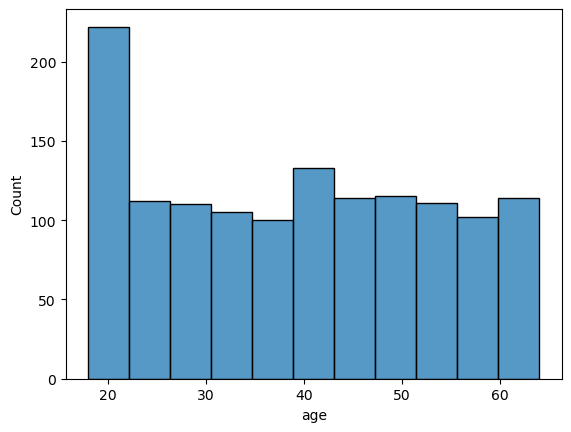

In [12]:
#check distributions of each column
sns.histplot(df, x='age',bins='fd')
plt.show()

In [13]:
# #check distributions of each column
# for col in df.columns:

#     sns.histplot(df, x=col,bins='fd')
#     plt.show()

#works well but not for all the columns like sex, smoker, region & children

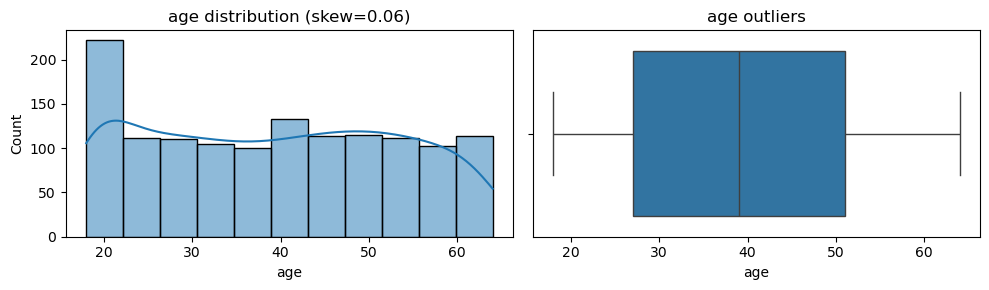

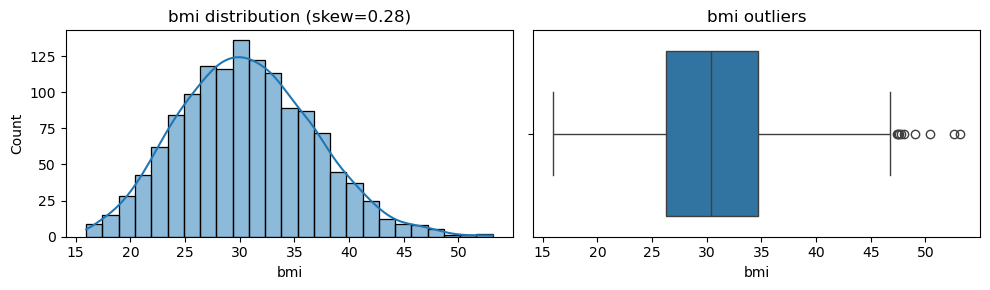

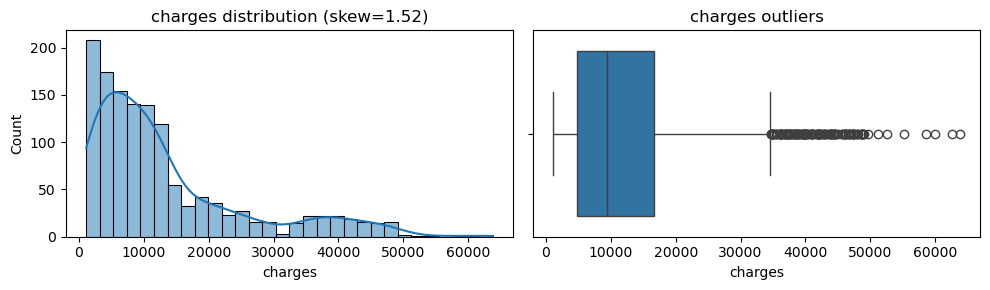

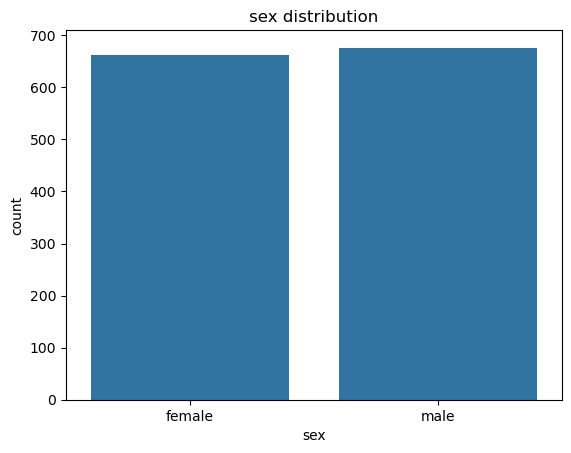

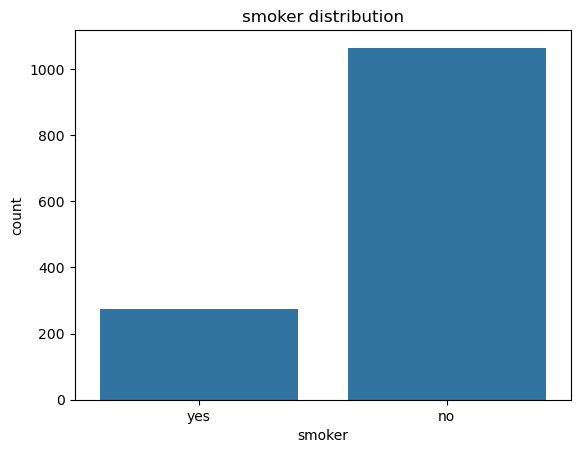

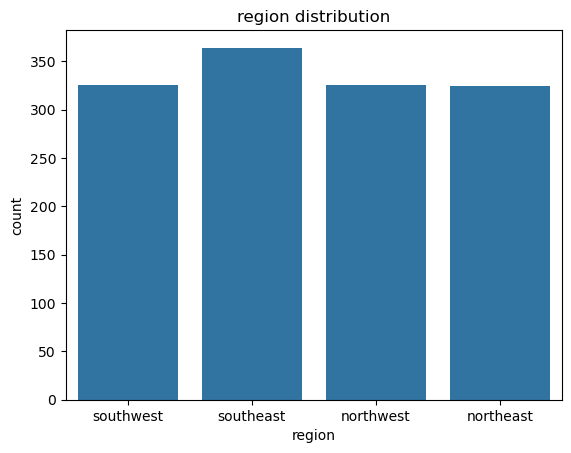

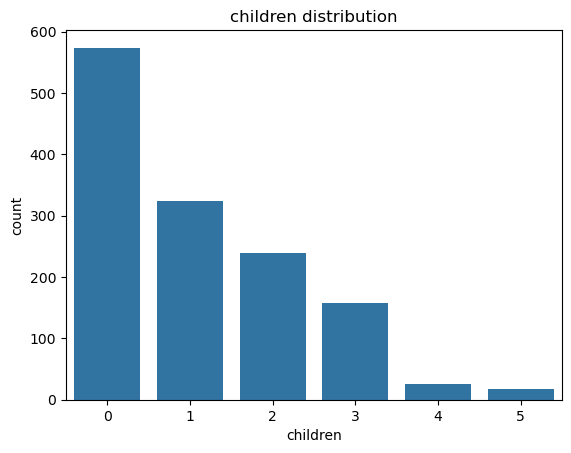

In [14]:
num_cols = ['age', 'bmi', 'charges']
cat_cols = ['sex', 'smoker', 'region', 'children']

#numeric: histograms + skew
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df, x=col, bins='fd', kde=True, ax=ax[0])
    ax[0].set_title(f'{col} distribution (skew={df[col].skew():.2f})')
    sns.boxplot(df, x=col, ax=ax[1])
    ax[1].set_title(f'{col} outliers')
    plt.tight_layout()
    plt.show()

#categorical: counts
for col in cat_cols:
    sns.countplot(df, x=col)
    plt.title(f'{col} distribution')
    plt.show()

Seems most of the columns are not normally distributed. A special note on the `smoker` column that is skewed.


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
## bivariate analysis
""" 
- bmi & age
- smoker & region
- charges & children
- charges, region

--- sex, charges 
--- age, charges
--- bmi, charges
--- smorker, charges

<multivariate>
- bmi, age, sex
- charges, region, smoker

--- bmi, smoker, charges
"""

' \n- bmi & age\n- smoker & region\n- charges & children\n- charges, region\n\n--- sex, charges \n--- age, charges\n--- bmi, charges\n--- smorker, charges\n\n<multivariate>\n- bmi, age, sex\n- charges, region, smoker\n\n--- bmi, smoker, charges\n'

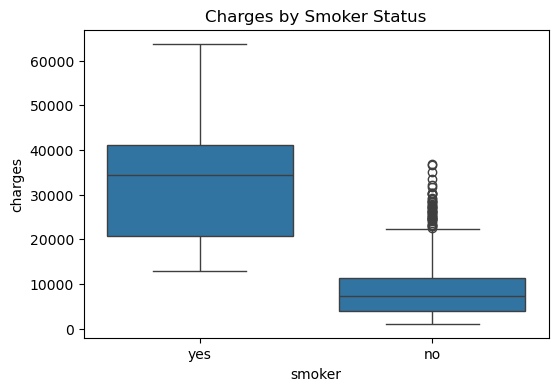

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by Smoker Status')
plt.show()

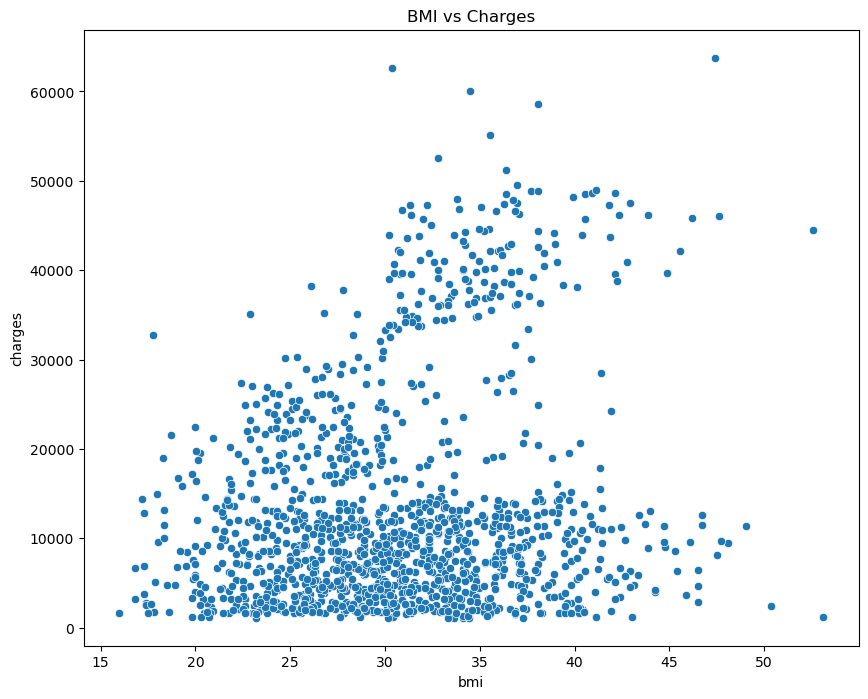

In [18]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('BMI vs Charges')
plt.show()

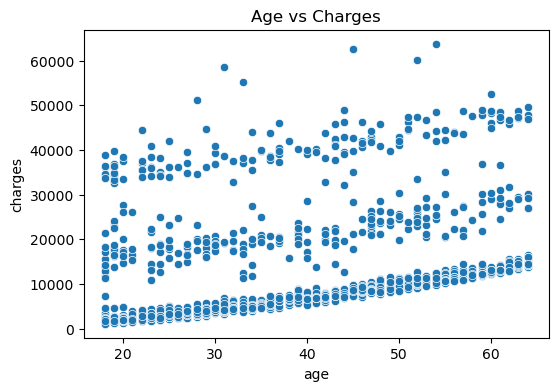

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Age vs Charges')
plt.show()

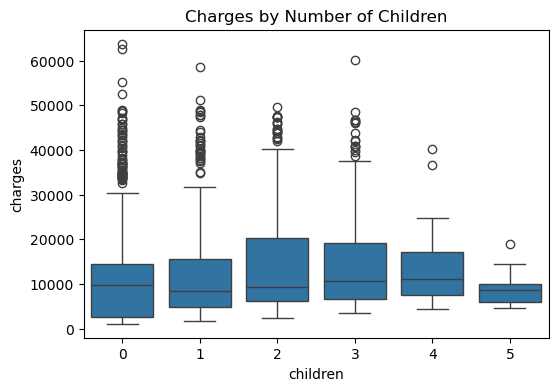

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='children', y='charges')
plt.title('Charges by Number of Children')
plt.show()

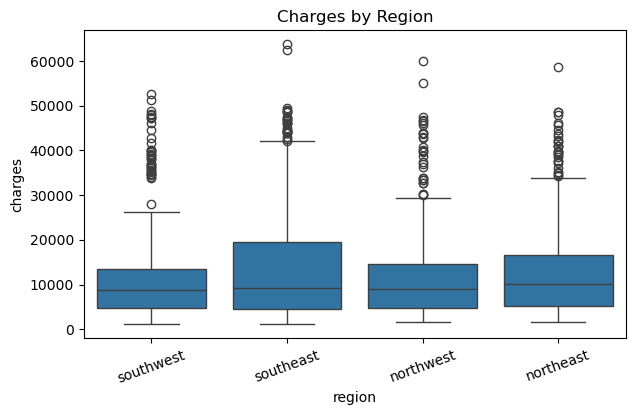

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges by Region')
plt.xticks(rotation=20)
plt.show()

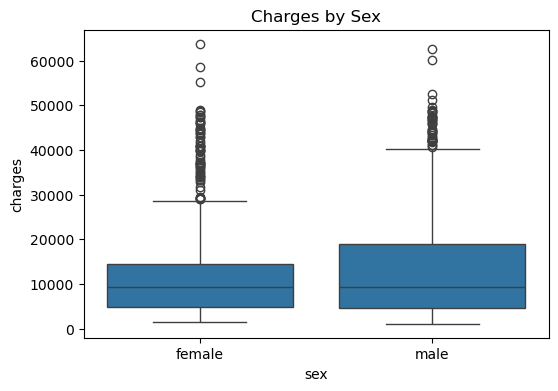

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Charges by Sex')
plt.show()

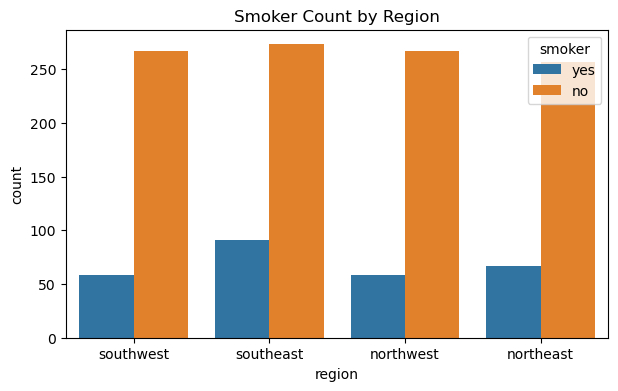

In [23]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='region', hue='smoker')
plt.title('Smoker Count by Region')
plt.show()

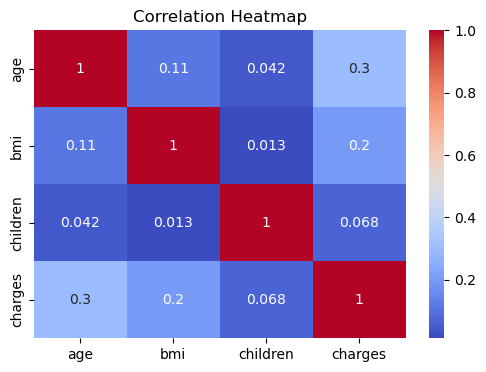

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

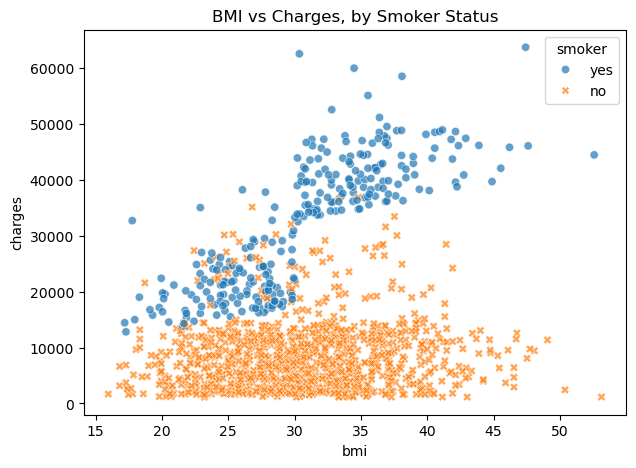

In [25]:
#### multivariate analysis

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='smoker', alpha=0.7)
plt.title('BMI vs Charges, by Smoker Status')
plt.show()

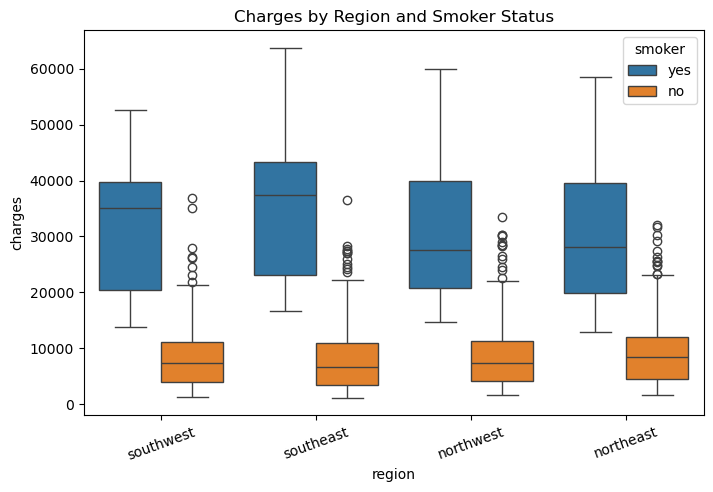

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region', y='charges', hue='smoker')
plt.title('Charges by Region and Smoker Status')
plt.xticks(rotation=20)
plt.show()

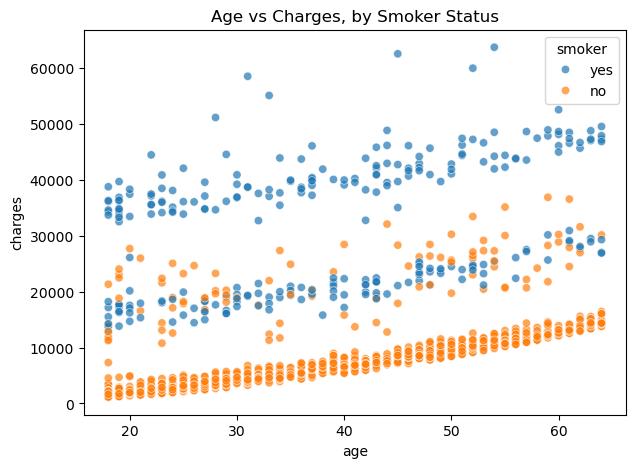

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Age vs Charges, by Smoker Status')
plt.show()

### Modelling
Now we'll move into modelling starting off with a simple regression model.

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [30]:
X = df.drop(columns='charges')
y = df['charges']

In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 62.8+ KB


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X['smoker']) #stratifying on smoker because of imbalance

categorical_cols = ['sex', 'smoker', 'region']
log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')


def evaluate(y_true, y_pred, name):
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAE:  {mae:,.2f}")
    return {'model': name, 'RMSE': rmse, 'R2': r2, 'MAE': mae}

results = []
#design a pipeline for column transformation and modelling
# transformer = FunctionTransformer(np.log1p)
# transformed_data = transformer.transform(df[["..."]])



In [50]:
numeric_log_cols = ['bmi']          # <-- update based on your actual skew() results
numeric_passthrough_cols = ['age', 'children']

preprocessor_1 = ColumnTransformer(
    transformers=[
        ('log_num', log_transformer, numeric_log_cols),
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

pipe_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('regressor', LinearRegression())
])

pipe_1.fit(X_train, y_train)
y_pred_1 = pipe_1.predict(X_test)
results.append(evaluate(y_test, y_pred_1, "Pipeline 1: Log skewed cols only"))

Pipeline 1: Log skewed cols only
RMSE: 5,701.34
R²:   0.7885
MAE:  4,087.84


In [55]:
df['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [52]:
#log transform everything numeric
numeric_log_cols_all = ['age', 'bmi', 'children']

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('log_num', log_transformer, numeric_log_cols_all),
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

pipe_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('regressor', LinearRegression())
])

pipe_2.fit(X_train, y_train)
y_pred_2 = pipe_2.predict(X_test)
results.append(evaluate(y_test, y_pred_2, "Pipeline 2: Log all numeric"))

Pipeline 2: Log all numeric
RMSE: 5,812.87
R²:   0.7801
MAE:  4,179.40


In [54]:
#no log transformation only ohe
preprocessor_3 = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # age, bmi, children pass through untouched
)

pipe_3 = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', LinearRegression())
])

pipe_3.fit(X_train, y_train)
y_pred_3 = pipe_3.predict(X_test)
results.append(evaluate(y_test, y_pred_3, "Pipeline 3: No log, OHE only"))

Pipeline 3: No log, OHE only
RMSE: 5,716.97
R²:   0.7873
MAE:  4,036.07


From all three approaches the MAE and RMSE are high and not exactly selling confidence. Therefore we will move to a diagnosis and see if the `smoker` column actually affects our models and we'll use our best pipeline to do this.

In [56]:
#error broken down by smoker status
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_1 
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])

print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     3067.146035
yes    8022.687098
Name: abs_error, dtype: float64


### Feature Engineering
As suspected, the `smoker MAE (~$8,023)` is **2.6x** higher than `non-smoker MAE (~$3,067)`. Next course of action is to add an interaction term between the **smoker column and bmi** to assess performance.

In [57]:
#feature engineering: BMI × Smoker interaction
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
X_train_fe['bmi_smoker'] = X_train_fe['bmi'] * (X_train_fe['smoker'] == 'yes').astype(int)
X_test_fe['bmi_smoker'] = X_test_fe['bmi'] * (X_test_fe['smoker'] == 'yes').astype(int)

#updated preprocessor ---> no log, now passthrough includes bmi_smoker
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker all pass through
)

pipe_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('regressor', LinearRegression())
])

pipe_fe.fit(X_train_fe, y_train)
y_pred_fe = pipe_fe.predict(X_test_fe)
results.append(evaluate(y_test, y_pred_fe, "Linear Reg + BMI×Smoker interaction"))


Linear Reg + BMI×Smoker interaction
RMSE: 4,624.93
R²:   0.8608
MAE:  2,771.91


In [58]:
#check if smoker-segment error improved
X_test_fe_copy = X_test_fe.copy()
X_test_fe_copy['actual'] = y_test.values
X_test_fe_copy['predicted'] = y_pred_fe
X_test_fe_copy['abs_error'] = np.abs(X_test_fe_copy['actual'] - X_test_fe_copy['predicted'])
print(X_test_fe_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2531.530079
yes    3698.600956
Name: abs_error, dtype: float64


There is significant improvement to the numbers from **2.6x to 1.5x**. The model can now separate "smoker with low BMI" from "smoker with high BMI" instead of treating all smokers as one group with one flat effect.

In [59]:
X_test_fe_copy['error'] = X_test_fe_copy['actual'] - X_test_fe_copy['predicted']
X_test_fe_copy.nlargest(5, 'error')[['bmi', 'smoker', 'age', 'actual', 'predicted', 'error']]

,bmi,smoker,age,actual,predicted,error
1012,33.330,no,61,36580.28216,15290.111345,21290.170815
599,37.525,no,52,33471.97189,12487.315705,20984.656185
987,27.645,no,45,28340.18885,10037.686240,18302.502610
102,30.115,no,18,21344.84670,3501.433532,17843.413168
539,31.350,no,53,27346.04207,10512.776012,16833.266058


From the output above there seems to be a potential **latent** group yet to be discovered within the group.

In [60]:
#lets attempt a linear feature between age and bmi as a latent feature
X_train_a = X_train.copy()
X_test_a = X_test.copy()

X_train_a['bmi_smoker'] = X_train_a['bmi'] * (X_train_a['smoker'] == 'yes').astype(int)
X_test_a['bmi_smoker'] = X_test_a['bmi'] * (X_test_a['smoker'] == 'yes').astype(int)

X_train_a['age_bmi'] = X_train_a['age'] * X_train_a['bmi']
X_test_a['age_bmi'] = X_test_a['age'] * X_test_a['bmi']

preprocessor_a = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker, age_bmi all pass through
)

pipe_a = Pipeline(steps=[
    ('preprocessor', preprocessor_a),
    ('regressor', LinearRegression())
])

pipe_a.fit(X_train_a, y_train)
y_pred_a = pipe_a.predict(X_test_a)
results.append(evaluate(y_test, y_pred_a, "Linear Reg + bmi_smoker + age_bmi"))


Linear Reg + bmi_smoker + age_bmi
RMSE: 4,634.89
R²:   0.8602
MAE:  2,767.78


In [61]:
#segment check
X_test_a_copy = X_test_a.copy()
X_test_a_copy['actual'] = y_test.values
X_test_a_copy['predicted'] = y_pred_a
X_test_a_copy['abs_error'] = np.abs(X_test_a_copy['actual'] - X_test_a_copy['predicted'])
print(X_test_a_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2533.057787
yes    3672.662900
Name: abs_error, dtype: float64


Not a significant improvement, lets attempt another latent feature.

In [62]:
#age_bmi_smoker but multplying the non-smoker with 0 
X_train_b = X_train.copy()
X_test_b = X_test.copy()

X_train_b['bmi_smoker'] = X_train_b['bmi'] * (X_train_b['smoker'] == 'yes').astype(int)
X_test_b['bmi_smoker'] = X_test_b['bmi'] * (X_test_b['smoker'] == 'yes').astype(int)

X_train_b['age_bmi_smoker'] = X_train_b['age'] * X_train_b['bmi'] * (X_train_b['smoker'] == 'yes').astype(int)
X_test_b['age_bmi_smoker'] = X_test_b['age'] * X_test_b['bmi'] * (X_test_b['smoker'] == 'yes').astype(int)

preprocessor_b = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker, age_bmi_smoker all pass through
)

pipe_b = Pipeline(steps=[
    ('preprocessor', preprocessor_b),
    ('regressor', LinearRegression())
])

pipe_b.fit(X_train_b, y_train)
y_pred_b = pipe_b.predict(X_test_b)
results.append(evaluate(y_test, y_pred_b, "Linear Reg + bmi_smoker + age_bmi_smoker"))

Linear Reg + bmi_smoker + age_bmi_smoker
RMSE: 4,626.51
R²:   0.8607
MAE:  2,771.96


In [63]:
#segment check
X_test_b_copy = X_test_b.copy()
X_test_b_copy['actual'] = y_test.values
X_test_b_copy['predicted'] = y_pred_b
X_test_b_copy['abs_error'] = np.abs(X_test_b_copy['actual'] - X_test_b_copy['predicted'])
print(X_test_b_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2530.041580
yes    3704.551477
Name: abs_error, dtype: float64


Linear regression with feature engineering seems to have hit a wall in improvement, thus we move into a non-linear model, we'll start with a **decision tree** then move into ensemble with **Random Forest.**

In [76]:
from sklearn.tree import DecisionTreeRegressor

pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor_3),   # original OHE-only preprocessor, no log/interaction terms needed
    ('regressor', DecisionTreeRegressor(max_depth=5, random_state=254))
])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt, "Decision Tree"))


Decision Tree
RMSE: 4,444.34
R²:   0.8715
MAE:  2,543.18


In [77]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2595.525145
yes    2341.393313
Name: abs_error, dtype: float64


In [78]:
print("Train R²:", pipe_dt.score(X_train, y_train))
print("Test R²:", pipe_dt.score(X_test, y_test))

Train R²: 0.8801235028034052
Test R²: 0.8714592838031163


Fairly good performance, lets improve on this with hyperparameter tuning before ensemble learning.

In [80]:
param_grid = {
    'regressor__max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 5, 10, 20],
    'regressor__max_features': [None, 'sqrt', 'log2']
}

pipe_dt_tune = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

grid_search = GridSearchCV(
    estimator=pipe_dt_tune,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',   # optimizes for RMSE
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


{'regressor__max_depth': 5,
 'regressor__max_features': None,
 'regressor__min_samples_leaf': 5,
 'regressor__min_samples_split': 2}

In [81]:
print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best params: {'regressor__max_depth': 5, 'regressor__max_features': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
Best CV RMSE: 4694.5358680451445


In [83]:
best_dt = grid_search.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt_tuned, "Decision Tree (tuned)"))


Decision Tree (tuned)
RMSE: 4,468.02
R²:   0.8701
MAE:  2,580.20


In [84]:
#overfit check
print("Train R²:", best_dt.score(X_train, y_train))
print("Test R²:", best_dt.score(X_test, y_test))


Train R²: 0.8777532513681087
Test R²: 0.8700863999544934


In [85]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2595.525145
yes    2521.109554
Name: abs_error, dtype: float64


In [87]:
#put all these in one code cell
y_pred_dt_tuned = best_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt_tuned, "Decision Tree (tuned)"))

print("Train R²:", best_dt.score(X_train, y_train))
print("Test R²:", best_dt.score(X_test, y_test))

X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

Decision Tree (tuned)
RMSE: 4,468.02
R²:   0.8701
MAE:  2,580.20
Train R²: 0.8777532513681087
Test R²: 0.8700863999544934
smoker
no     2595.525145
yes    2521.109554
Name: abs_error, dtype: float64


The tuned decision tree is essentially tied with (slightly worse than) our engineered linear regression. Lets see if random forest will do better.

In [88]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))



Random Forest
RMSE: 4,486.17
R²:   0.8690
MAE:  2,540.83


In [89]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_rf
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2587.572507
yes    2360.641783
Name: abs_error, dtype: float64


In [90]:
#overfitting check
print("Train R²:", pipe_rf.score(X_train, y_train))
print("Test R²:", pipe_rf.score(X_test, y_test))

Train R²: 0.911266035815268
Test R²: 0.8690287313109674


Very promising results from the initial random forest, lets perform a gridsearch for hyperparameter tuning and see whether it improves.

In [91]:
param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [4, 5, 6, 8, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}

pipe_rf_tune = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search_rf = GridSearchCV(
    estimator=pipe_rf_tune,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)
print("Best RF params:", grid_search_rf.best_params_)
print("Best CV RMSE:", -grid_search_rf.best_score_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best RF params: {'regressor__max_depth': 4, 'regressor__min_samples_leaf': 5, 'regressor__n_estimators': 100}
Best CV RMSE: 4558.03604694573


In [93]:
best_rf = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf_tuned, "Random Forest (tuned)"))



Random Forest (tuned)
RMSE: 4,408.70
R²:   0.8735
MAE:  2,516.07


In [94]:
#overfit check
print("Train R²:", best_rf.score(X_train, y_train))
print("Test R²:", best_rf.score(X_test, y_test))

Train R²: 0.8735229002896683
Test R²: 0.8735127271193945


In [95]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_rf_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())


smoker
no     2540.057249
yes    2423.581700
Name: abs_error, dtype: float64


In [96]:
#top-5 errors; does it finally catch the non-smoker/high-BMI/older group?
X_test_copy['error'] = y_test.values - y_pred_rf_tuned
print(X_test_copy.nlargest(5, 'error')[['bmi','smoker','age','actual','predicted','error']])


         bmi smoker  age       actual     predicted         error
599   37.525     no   52  33471.97189  13268.023397  20203.948493
1012  33.330     no   61  36580.28216  16650.696860  19929.585300
987   27.645     no   45  28340.18885   9143.314926  19196.873924
102   30.115     no   18  21344.84670   2600.546256  18744.300444
115   28.595     no   60  30259.99556  13075.299804  17184.695756


In [97]:
#feature importance
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print(importance_df)

                        feature  importance
1        onehot_cat__smoker_yes    0.703994
6                remainder__bmi    0.176226
5                remainder__age    0.110972
7           remainder__children    0.008144
3  onehot_cat__region_southeast    0.000286
0          onehot_cat__sex_male    0.000153
4  onehot_cat__region_southwest    0.000137
2  onehot_cat__region_northwest    0.000088


The model explains **87%** of cost variance, driven overwhelmingly by smoking status (**70%** importance), BMI, and age. 

However, a consistent subgroup - older, high-BMI non-smokers - remains underpredicted across every model I tried, including `Random Forest`. This points to an unobserved risk factor, like a pre-existing condition, not captured in this dataset. In production, I'd recommend enriching this model with medical history or claims history data to close that gap.